In [3]:
from collections import Counter
import argparse
import os
import json
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

#add ../ to the path
import sys
sys.path.append('../')


from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, compute_cov)

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        #self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
        
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)

import sys

In [4]:
# gt_spacegroups = [symmetryops(crystal.structure, 0.01)[1] for crystal in gt_crys]

# gt_spacegroups

# import pandas as pd

# train_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20_final/train.csv")

# train_df

# from typing import Any, Dict

# import hydra
# import numpy as np
# import omegaconf
# import torch
# import pytorch_lightning as pl
# import torch.nn as nn
# from torch.nn import functional as F
# from torch_scatter import scatter
# from tqdm import tqdm

# from cdvae.common.utils import PROJECT_ROOT
# from cdvae.common.data_utils import (
#     EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
#     frac_to_cart_coords, min_distance_sqr_pbc)
# from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
# from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

# #added by Tsach
# from pymatgen.core.structure import Structure
# from pymatgen.core.periodic_table import Element
# from pymatgen.core.lattice import Lattice
# from pymatgen.analysis.diffraction.xrd import XRDCalculator
# #import Batch
# from torch_geometric.data import Batch
# xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
# torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor

# import time
# import argparse
# import torch

# from tqdm import tqdm
# from torch.optim import Adam
# from pathlib import Path
# from types import SimpleNamespace
# from torch_geometric.data import Batch
# from torch_geometric.data.separate import separate

# #import a library that allows you to reload a module
# from importlib import reload

# from eval_utils import load_model

# import itertools
# import numpy as np
# import torch
# import hydra

# from scipy.spatial.distance import pdist
# from scipy.spatial.distance import cdist
# from hydra.experimental import compose
# from hydra import initialize_config_dir
# from pathlib import Path

# import smact
# from smact.screening import pauling_test

# from cdvae.common.constants import CompScalerMeans, CompScalerStds
# from cdvae.common.data_utils import StandardScaler, chemical_symbols
# #from cdvae.pl_data.dataset import TensorCrystDataset
# from cdvae.pl_data.datamodule import worker_init_fn

# from torch_geometric.data import DataLoader

# CompScaler = StandardScaler(
#     means=np.array(CompScalerMeans),
#     stds=np.array(CompScalerStds),
#     replace_nan_token=0.)


# def load_model(model_path, load_data=False, testing=True, test_set_override=None):
#     with initialize_config_dir(str(model_path)):
#         if test_set_override is not None:
#             cfg = compose(config_name='hparams', overrides=[f"data.root_path=/home/gridsan/tmackey/cdvae/data/{test_set_override}",
#                                                             f"data.eval_model_name={test_set_override}"])
#             print("overriding data with ", test_set_override)
#         else:
#             cfg = compose(config_name='hparams')
#         model = hydra.utils.instantiate(
#             cfg.model,
#             optim=cfg.optim,
#             data=cfg.data,
#             logging=cfg.logging,
#             _recursive_=False,
#         )
#         ckpts = list(model_path.glob('*.ckpt'))
#         if len(ckpts) > 0:
#             ckpt_epochs = np.array(
#                 [int(ckpt.parts[-1].split('-')[0].split('=')[1]) for ckpt in ckpts])
#             ckpt = str(ckpts[ckpt_epochs.argsort()[-1]])
#         model = model.load_from_checkpoint(ckpt, strict=False)
#         model.lattice_scaler = torch.load(model_path / 'lattice_scaler.pt')
#         model.scaler = torch.load(model_path / 'prop_scaler.pt')

#         if load_data:
#             datamodule = hydra.utils.instantiate(
#                 cfg.data.datamodule, _recursive_=False, scaler_path=model_path
#             )
#             if testing:
#                 datamodule.setup()
#                 print(datamodule)
#                 print(datamodule.train_dataloader())
#                 test_loader = datamodule.train_dataloader()
#                 print(test_loader)
#             else:
#                 datamodule.setup()
#                 test_loader = datamodule.train_dataloader()[0]
#         else:
#             test_loader = None

#     return model, test_loader, cfg

# model_path = Path(model_path)
# model, test_loader, cfg = load_model(model_path, True)

# scaled_spacegroups = model.scaler.inverse_transform(spacegroup_num)

# scaled_spacegroups = scaled_spacegroups.cpu().numpy()

# gt_spacegroups_array = np.array(gt_spacegroups)

# gt_spacegroups_array = gt_spacegroups_array.reshape(256,1)

# import matplotlib.pyplot as plt

# plt.plot(scaled_spacegroups)
# plt.plot(gt_spacegroups_array)
# plt.xlim(0,10)

# scaled_spacegroups - gt_spacegroups_array

# np.sqrt(np.mean((scaled_spacegroups - gt_spacegroups_array)**2))

In [5]:
import os
import sys
import os
from contextlib import contextmanager
import warnings

def count_unique_crystals(pred_crys):
    unique_crystals = []
    is_unique_list = []
    for i in range(len(pred_crys) - 1):
        is_unique = True
        #determine if they are the sume 
        rec_evaluator = RecEval((len(pred_crys) - (i+1)) * [pred_crys[i]], pred_crys[(i + 1): len(pred_crys)])
        recon_metrics = rec_evaluator.get_metrics()
        numeric_metrics = np.array([0 if x is None else x for x in recon_metrics['rmsd_values']])

        #recon metrics rmsd_values will be greater than 0 if they are the same 
        #if the indices are different and the rmsd is none 
        if np.sum(numeric_metrics) != 0:
            is_unique = False
                
        is_unique_list.append(is_unique)
    
    is_unique_list.append(True)

    return is_unique_list

@contextmanager
def suppress_output():
    """
    A context manager to suppress print statements and warnings.
    """
    with open(os.devnull, 'w') as devnull, warnings.catch_warnings():
        old_stdout = sys.stdout
        sys.stdout = devnull
        warnings.simplefilter("ignore")
        try:
            yield
        finally:
            sys.stdout = old_stdout
            warnings.resetwarnings()

In [6]:
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer

def symmetryops(structure, symprec):
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_symbol = sga.get_space_group_symbol()
    space_group_number = sga.get_space_group_number()  # Get the space group number
    symmetrized_structure = sga.get_refined_structure()
    
    return space_group_symbol, space_group_number, symmetrized_structure

In [7]:
def get_unique_crystals(unique_list, pred_crystals): 
    return [pred_crystals[i] for i in range(len(pred_crystals)) if unique_list[i]]

In [8]:
import matplotlib.pyplot as plt
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.core.structure import Structure

# Example: Load structure from CIF file
# structure = Structure.from_file("your_structure.cif")

# Assuming you already have a pymatgen Structure object named `structure`

# Create an XRD calculator with Cu Kα radiation
xrd_calculator = XRDCalculator(wavelength='CuKa')

def xrd_plotter(structure1, structure2 = None, xlim = None): 
    # Calculate the XRD pattern
    pattern = xrd_calculator.get_pattern(structure1)
    
    if structure2: 
        pattern2 = xrd_calculator.get_pattern(structure2)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.vlines(pattern.x, 0, pattern.y, colors='blue', lw=0.5)
    if structure2: 
        plt.vlines(pattern2.x, 0, pattern2.y, colors='red', lw=0.5)
    plt.xlabel('2θ [degrees]')
    plt.ylabel('Intensity [arbitrary units]')
    plt.title('X-ray Diffraction Pattern')
    if xlim:
        plt.xlim(xlim[0], xlim[1]) 
    plt.grid()
    plt.show()

In [9]:
def get_correct_crystals(metrics, crys): 
    return [crys[i] for i in range(len(crys)) if metrics[i]]

In [10]:
def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None
    try: 
        predicted_property = data['predicted_property'][batch_idx]
    except Exception as e: 
        predicted_property = None

    return crys_array_list, true_crystal_array_list, predicted_property

In [11]:
from tqdm import tqdm

In [12]:
def all_results_retreival(recon_file_path, traditional_sampling = False, num_batches = 1, label = ""): 
    all_results = []
    all_gt = []
    for eval_num in tqdm(range(num_batches)): 
        file_path = recon_file_path
        if traditional_sampling:
            crys_array_list, true_crystal_array_list, _ = get_crystal_array_list(file_path, batch_idx=eval_num)
        else:
            if eval_num > 0: 
                if label == "": 
                    file_path = file_path[:-3]+ "__{}.pt".format(eval_num)
                else: 
                    file_path = file_path[:-3]+ "_{}.pt".format(eval_num)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)
            else: 
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

        all_results.append(crys_array_list)
        all_gt.append(true_crystal_array_list)
    
    return all_results, all_gt

def is_unique(list_of_structures, structure): 
    try: 
        results = RecEval(list_of_structures, len(list_of_structures) * [structure]).get_metrics()
    except: 
        results = {'rmsd_values': len(list_of_structures) * [None]}
    results_with_0 = [0 if x is None else x for x in results['rmsd_values']]
    if np.sum(results_with_0) > 0: 
        return False
    else:
        return True 

def evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = 1, traditional_sampling = False , all_results_matrix = True):
    mistake_counter = 0
    pred_spacegroups = []
    gt_spacegroups = []
    # total_is_unique_list = []
    total_rmsd = []
    for index in range(set_size): 
        pred_crys = []
        gt_crys_list = []
        for eval_num in range(num_batches):
            file_path = recon_file_path
            if traditional_sampling:
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path, batch_idx = eval_num)
            elif all_results_matrix: 
                crys_array_list = all_results[eval_num]
                true_crystal_array_list = all_gt[eval_num]
            else: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

            pred_crys.append(Crystal(crys_array_list[index]))    
            gt_crys_list.append(Crystal(true_crystal_array_list[index]))
            
#         unique_list = []
#         for index in range(len(pred_crys)):
#             if is_unique(pred_crys[:index], pred_crys[index]):
#                 unique_list.append(pred_crys[index]) 
        
#         total_is_unique_list.append(unique_list)
        
        g_structure =  gt_crys_list[0].structure
        gt_spacegroup, gt_sg_num, gt_symmetrized_structure = symmetryops(g_structure, 0.01)

        rec_evaluator = RecEval(pred_crys, gt_crys_list)
        try: 
            recon_metrics = rec_evaluator.get_metrics()
        except Exception as e: 
            print("")

        per_crystal_pred_sg = np.zeros(len(pred_crys))
        per_crystal_gt_sg = len(pred_crys) * [gt_sg_num]

        for batch_index in (range(len(pred_crys))): 
            p_structure = pred_crys[batch_index].structure

            a_structure = pred_crys[batch_index].structure
            try: 
                spacegroup, sg_num, symmetrized_structure = symmetryops(a_structure, 2)

                per_crystal_pred_sg[batch_index] = sg_num

            except: 
                continue

        total_rmsd.append(recon_metrics['rmsd_values'])
        pred_spacegroups.append(per_crystal_pred_sg)
        gt_spacegroups.append(per_crystal_gt_sg)
        
    pred_spacegroups = np.stack(pred_spacegroups)
    gt_spacegroups = np.stack(gt_spacegroups)
    
    return total_rmsd, pred_spacegroups, gt_spacegroups

In [13]:
import matplotlib.pyplot as plt

In [14]:
def statistics_gen(total_data): 
    total_data = np.stack(total_data)
    total_data_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_data])
    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    plt.plot(results_per_sample)
    return results_per_sample

In [15]:
def restricted_statistics(total_data, filter_data, xlim = None):
    #only get the entries in the total_data for which filter_data is nonzero 
    list_of_lists_filtered = []
    num_batches = len(total_data[0])
    for index in range(len(total_data)):
        sublist = total_data[index]
        filter_sublist = filter_data[index]
        list_of_lists_filtered.append([sublist[subindex] for subindex in range(len(sublist)) if filter_sublist[subindex] > 0])
    
    list_of_lists_filtered_padded = [(sublist + num_batches*[0])[:num_batches] for sublist in list_of_lists_filtered]
    total_data = np.stack(list_of_lists_filtered_padded)
    
    total_data = np.stack(total_data)
    total_data_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_data])
    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    plt.plot(results_per_sample)
    if xlim: 
        plt.xlim(xlim[0], xlim[1])
    return results_per_sample, total_data_array_cum_sum, total_data_array

Figure 1: Match rates across the entire test set for 0-4 samples overlaid with match rates across 5 batches for 0-4 samples

In [16]:
import eval_utils
import viz_utils
import importlib
importlib.reload(eval_utils)
importlib.reload(viz_utils)
from eval_utils import *
from viz_utils import * 

In [19]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf'
label = 'full_set_4_evals'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 4
all_results, all_gt = all_results_retreival(recon_file_path, num_batches, label = label)
set_size = len(all_results[0])
fs = "full_set_4_evals"

100%|██████████| 4/4 [00:03<00:00,  1.16it/s]


In [20]:
full_test_set_results = result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/full_set_4_evals')

Misclassification analysis

In [60]:
def matched_and_unmatched_compounds(total_data_array, all_results, all_gt): 
    total_matched_compounds = []
    total_unmatched_compounds = []
    for compound_index in range(len(total_data_array)): 
        matched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] >= 0]
        unmatched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] < 0]

        assert (len(matched_compounds) + len(unmatched_compounds)) == len(total_data_array[compound_index])
        
        total_matched_compounds.append(matched_compounds)
        total_unmatched_compounds.append(unmatched_compounds) 
        
    return total_matched_compounds, total_unmatched_compounds

def num_atoms_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_num_atoms = [strc.num_sites for strc in matched_pym_strc]
    unmatched_num_atoms = [strc.num_sites for strc in unmatched_pym_strc]
    
    return matched_num_atoms, unmatched_num_atoms

def composition_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_atomic_numbers = [strc.atomic_numbers for strc in matched_pym_strc]
    unmatched_atomic_numbers = [strc.atomic_numbers for strc in unmatched_pym_strc]
    
    matched_atomic_numbers_flattened = []
    unmatched_atomic_numbers_flattened = []
    for entry in matched_atomic_numbers: 
        matched_atomic_numbers_flattened += entry
        
    for entry in unmatched_atomic_numbers: 
        unmatched_atomic_numbers_flattened += entry
    
    return matched_atomic_numbers_flattened, unmatched_atomic_numbers_flattened

def spacegroup_number(structure, symprec = 0.01): 
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_number = sga.get_space_group_number()
    return space_group_number

def spacegroup_analysis(matched_pym_strc, unmatched_pym_strc, symprec = 0.01): 
    matched_sgs = [spacegroup_number(structure, symprec) for structure in matched_pym_strc]
    unmatched_sgs = [spacegroup_number(structure, symprec) for structure in unmatched_pym_strc]
    
    return matched_sgs, unmatched_sgs
    
def misclassification_analysis(total_data, all_gt): 
    total_data_array = np.array([[-1 if np.isnan(x) else x for x in sublist] for sublist in total_data])
    total_matched_compounds, total_unmatched_compounds = matched_and_unmatched_compounds(total_data_array, all_gt, all_gt)

    #filter out empty lists 
    total_matched_compounds_filtered = [total_matched_compound for total_matched_compound in total_matched_compounds if total_matched_compound != []]
    total_unmatched_compounds_filtered = [total_unmatched_compound for total_unmatched_compound in total_unmatched_compounds if total_unmatched_compound != []]
    
    #create crystal structure objects from the entries
    matched_structures = [Crystal(compound[0]) for compound in total_matched_compounds_filtered]
    unmatched_structures = [Crystal(compound[0]) for compound in total_unmatched_compounds_filtered]
    
    #create pymatgen crystal structures from the entries
    matched_pym_strc = [strc.structure for strc in matched_structures]
    unmatched_pym_strc = [strc.structure for strc in unmatched_structures]
    
    #analyze the num atoms
    matched_num_atoms, unmatched_num_atoms = num_atoms_analysis(matched_pym_strc, unmatched_pym_strc)
    
    #analyze the composition 
    matched_composition, unmatched_composition = composition_analysis(matched_pym_strc, unmatched_pym_strc) 
    
    #analyze the spacegroup 
    matched_sgs, unmatched_sgs = spacegroup_analysis(matched_pym_strc, unmatched_pym_strc) 

    return (matched_structures, unmatched_structures, matched_pym_strc, unmatched_pym_strc, matched_num_atoms, 
            unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) 

In [61]:
def misclass_plotter(grp1, grp2, bins=20, defined_spacing=False, title='', xlabel='', ylabel='', 
                     legend_labels=('Matched', 'Missed'), axis_font_size=12, color_grp1='darkviolet', color_grp2='dodgerblue'):
    fig, ax = plt.subplots()
    plt.hist(grp1, bins=bins, color=color_grp1, label=legend_labels[0])
    plt.hist(grp2, bins=bins, color=color_grp2, alpha=0.5, label=legend_labels[1])
    if defined_spacing:
        xmin, xmax = min(min(grp1), min(grp2)), max(max(grp1), max(grp2))
        plt.xticks(range(int(xmin), int(xmax) + 1, 1))
    plt.title(title)
    plt.xlabel(xlabel, fontsize=axis_font_size)
    plt.ylabel(ylabel, fontsize=axis_font_size)
    plt.legend()
    plt.xticks(fontsize=axis_font_size)
    plt.yticks(fontsize=axis_font_size)
    plt.show()
    
    # Save the figure as a PDF file
    fig.savefig(f'/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/{title}.pdf')


def visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs):
    misclass_plotter(matched_num_atoms, unmatched_num_atoms, 20, True, 
                     title='Matched and Missed nSites Distribution', xlabel='Number of sites in the unit cell', ylabel='Count across the full test set ')
    #misclass_plotter(matched_composition, unmatched_composition)
    misclass_plotter(matched_sgs, unmatched_sgs, 40, False, 
                     title='Matched and Missed Spacegroup Distribution', xlabel='Spacegroup number', ylabel='Count across the full test set ')
    
def misclassification_visualization(total_rmsd, all_gt): 
    (_, _, matched_pym, unmatched_pym, matched_num_atoms, unmatched_num_atoms, 
 matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) = misclassification_analysis(total_rmsd, all_gt)
    return matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs

In [89]:
matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs = misclassification_visualization(full_test_set_results.total_rmsd.T, all_gt)

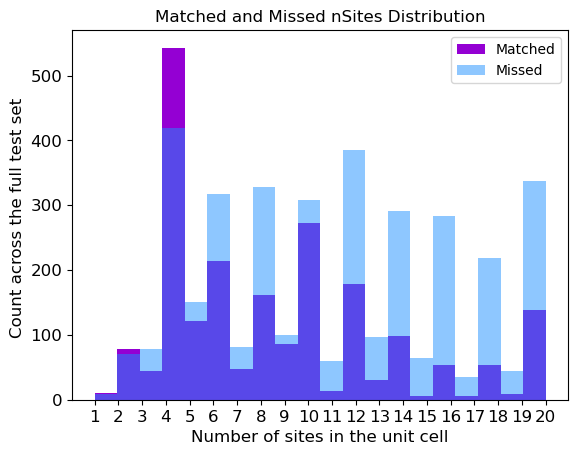

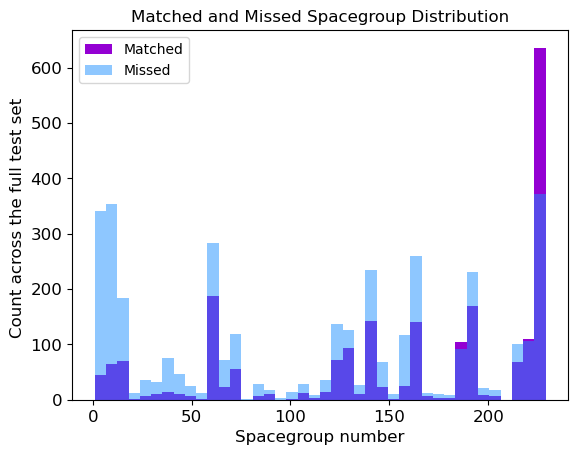

In [90]:
visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs)

In [95]:
# Find the maximum length among the lists
max_len = max(len(matched_num_atoms), len(unmatched_num_atoms), len(matched_composition),
              len(unmatched_composition), len(matched_sgs), len(unmatched_sgs))

# Function to pad lists with NaNs to make them all the same length
pad_list = lambda lst: lst + [None] * (max_len - len(lst))

# Create a DataFrame with the padded lists
df = pd.DataFrame({
    'matched_num_atoms': pad_list(matched_num_atoms),
    'unmatched_num_atoms': pad_list(unmatched_num_atoms),
    'matched_composition': pad_list(matched_composition),
    'unmatched_composition': pad_list(unmatched_composition),
    'matched_sgs': pad_list(matched_sgs),
    'unmatched_sgs': pad_list(unmatched_sgs),
})

,matched_num_atoms,unmatched_num_atoms,matched_composition,unmatched_composition,matched_sgs,unmatched_sgs
0,9.0,8.0,92.0,66,189.0,62.0
1,8.0,18.0,92.0,66,62.0,191.0
2,18.0,14.0,92.0,66,191.0,166.0
3,4.0,8.0,31.0,66,225.0,129.0
4,14.0,4.0,31.0,14,166.0,225.0
...,...,...,...,...,...,...
40136,NaN,NaN,NaN,48,NaN,NaN
40137,NaN,NaN,NaN,29,NaN,NaN
40138,NaN,NaN,NaN,29,NaN,NaN
40139,NaN,NaN,NaN,29,NaN,NaN


In [96]:
#save to "misclassification_csv" in /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data
dir = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data"
df.to_csv(f"{dir}/misclassification_csv.csv")

In [97]:
from periodic_trends import plotter

In [98]:
from pymatgen.core import Element

def count_elements(atomic_numbers):
    symbol_count = {}
    for number in atomic_numbers:
        element = Element.from_Z(number)
        symbol = element.symbol
        if symbol in symbol_count:
            symbol_count[symbol] += 1
        else:
            symbol_count[symbol] = 1
    return symbol_count
def calculate_ratios(matched, nomatch):
    ratios = {}
    for element, count in matched.items():
        if count > 10:
            if element in nomatch:
                ratios[element] = nomatch[element] / count
            else:
                ratios[element] = "No Match or Zero in Matched"
    return ratios
def sort_dict_by_values(d):
    sorted_items = sorted(d.items(), key=lambda x: x[1], reverse = True)
    sorted_dict = dict(sorted_items)
    return sorted_dict
# Example usage
matched_result = count_elements(matched_composition)
unmatched_results = count_elements(unmatched_composition)
ratios = calculate_ratios(matched_result, unmatched_results)
sorted_ratios = sort_dict_by_values(ratios)

In [99]:
sorted_ratios

{'H': 10.66,
 'B': 8.352941176470589,
 'N': 6.206521739130435,
 'Te': 5.31496062992126,
 'Li': 4.868932038834951,
 'C': 4.101010101010101,
 'Na': 3.7142857142857144,
 'As': 3.53125,
 'Mo': 3.5157894736842104,
 'S': 3.359550561797753,
 'I': 3.30718954248366,
 'V': 3.276315789473684,
 'Mn': 3.2175925925925926,
 'Nb': 3.1956521739130435,
 'Se': 3.1540983606557376,
 'K': 2.992857142857143,
 'Cr': 2.9363636363636365,
 'Be': 2.8974358974358974,
 'Ta': 2.8253968253968256,
 'O': 2.715450035435861,
 'P': 2.701863354037267,
 'W': 2.689655172413793,
 'Co': 2.5454545454545454,
 'Ti': 2.524390243902439,
 'F': 2.5118549511854953,
 'U': 2.3488372093023258,
 'Pb': 2.3176470588235296,
 'Ba': 2.167539267015707,
 'Fe': 2.1603498542274053,
 'Bi': 2.1379310344827585,
 'La': 2.1291866028708135,
 'Si': 2.1192660550458715,
 'Br': 1.9955156950672646,
 'Cu': 1.9869451697127938,
 'Cl': 1.964705882352941,
 'Mg': 1.9109589041095891,
 'Sn': 1.8860294117647058,
 'Ni': 1.8669724770642202,
 'Sr': 1.851528384279476,
 '

In [100]:
#read in a csv template to use
import pandas as pd
dir ="/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing"
misclassification_df = pd.read_csv(os.path.join(dir, "missed_composition_ratios.csv"), header = None)

In [101]:
for index in range(len(misclassification_df)):
    try: 
        misclassification_df[1].iloc[index] = sorted_ratios[misclassification_df[0][index]]
    except:
        continue

/tmp/ipykernel_1295639/2360499639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassification_df[1].iloc[index] = sorted_ratios[misclassification_df[0][index]]
/tmp/ipykernel_1295639/2360499639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassification_df[1].iloc[index] = sorted_ratios[misclassification_df[0][index]]
/tmp/ipykernel_1295639/2360499639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassifica

In [102]:
misclassification_df.to_csv("/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data/missed_composition_ratios.csv", index = False, header = False)

In [103]:
plotter("/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data/missed_composition_ratios.csv", 
output_filename = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/MP_20_Testing/result_data/periodic_heatmap.html")

figure(id='p1005', ...)

100%|██████████| 36/36 [00:04<00:00,  8.25it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 117.41it/s]


[True, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 86.88it/s]


...

100%|██████████| 36/36 [00:00<00:00, 46.20it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 38.68it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:08<00:00,  4.30it/s]


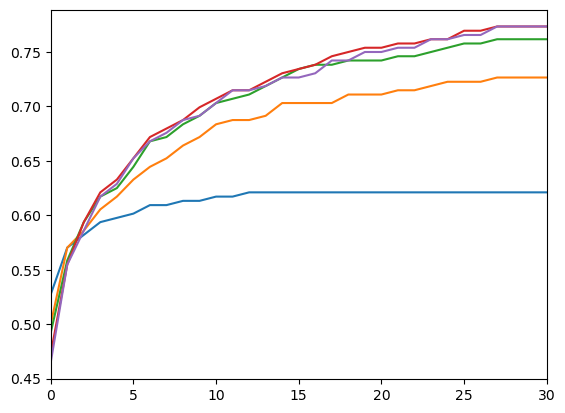

In [92]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/pf_noaug'
label = 'sampling5'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 36
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)

total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

for tol in np.arange(0, 200, 50):
    spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
    _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,30])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

I have gotten some strange results from the ground truth crystal structures. I will look into them here

In [16]:
def all_results_retreival(recon_file_path, traditional_sampling = False, num_batches = 1): 
    all_results = []
    all_gt = []
    for eval_num in tqdm(range(num_batches)): 
        file_path = recon_file_path
        if traditional_sampling:
            crys_array_list, true_crystal_array_list, _ = get_crystal_array_list(file_path, batch_idx=eval_num)
        else:
            if eval_num > 0: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num - 1)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)
            else: 
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

        all_results.append(crys_array_list)
        all_gt.append(true_crystal_array_list)
    
    return all_results, all_gt

In [18]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/nopf_noaug'
recon_file_path = get_file_paths(model_path, 'recon',label='')
num_batches = 30
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches)

100%|██████████| 30/30 [00:03<00:00,  7.86it/s]


In [83]:
def gt_crystal_examination(all_gt, set_size = 256, num_batches = 1):
    gt_crystal_list_one = []
    gt_crystal_list_two = []
    for index in range(set_size):
        for batch_num in range(num_batches - 1): 
            pred_crys = []
            gt_crys_list = []
            try: 
                crystal_match = StructureMatcher(stol=0.5, angle_tol=10, ltol=0.3).get_rms_dist(
                        Crystal(all_gt[batch_num][index]).structure, Crystal(all_gt[batch_num+1][index]).structure)
            except: 
                crystal_match = None

            if crystal_match is None:
                print("not the same") 
                gt_crystal_list_one.append(all_gt[0][index])
                gt_crystal_list_two.append(all_gt[1][index])
            
    return gt_crystal_list_one, gt_crystal_list_two

In [84]:
gt_crystal_list_one, gt_crystal_list_two = gt_crystal_examination(all_gt, set_size = 256, num_batches = 20)

In [85]:
len(gt_crystal_list_one)

0